In [1]:
import json, time, random, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from scipy.stats import wilcoxon
 
from data.load_data import load_hevy, load_kaggle
from data.preprocess import preprocess
from data.sequence_builder import build_sequences
from utils.scaler import fit_scaler, transform_sequences
from training.train_lstm import train_lstm
from training.finetune_walk import finetune_lstm_walkforward
from training.train_baselines import train_baselines

LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\data\load_data.py
LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\data\preprocess.py
LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\data\sequence_builder.py
LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\utils\scaler.py
LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\models\lstm.py
LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\utils\split.py
LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\training\train_lstm.py
LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\training\finetune_walk.py
LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\training\train_baselines.py


In [2]:
#data prep

exercises = ['Bench Press', 'Lat Pulldown']
feature_cols = ['weight_kg', 'reps', 'session_volume', 'prev_top_weight',
                'prev_top_reps', 'days_since_last', 'trend_slope']
target_cols = ['next_weight', 'next_reps']
seq_len = 5
 
hevy_prep   = preprocess(load_hevy('data/new_workout_data.csv'), exercises)
kaggle_prep = preprocess(load_kaggle('data/Hevy_workouts_log_100_weeks.csv'), exercises)
 
X_kaggle, y_kaggle, ex_kaggle = build_sequences(kaggle_prep, feature_cols, target_cols, seq_len)
X_hevy,   y_hevy,   ex_hevy   = build_sequences(hevy_prep,   feature_cols, target_cols, seq_len)
 
print("Sessions  Kaggle:", kaggle_prep.groupby('exercise_title').size().to_dict(),
      "| Hevy:", hevy_prep.groupby('exercise_title').size().to_dict())
print("Windows   Kaggle:", pd.Series(ex_kaggle).value_counts().to_dict(),
      "| Hevy:", pd.Series(ex_hevy).value_counts().to_dict())

Sessions  Kaggle: {'Bench Press': 101, 'Lat Pulldown': 89} | Hevy: {'Bench Press': 61, 'Lat Pulldown': 56}
Windows   Kaggle: {'Bench Press': 97, 'Lat Pulldown': 85} | Hevy: {'Bench Press': 57, 'Lat Pulldown': 52}


In [3]:
#scaling the data

scaler = fit_scaler(X_kaggle, X_hevy)

X_kaggle_scaled = transform_sequences(X_kaggle, scaler)
X_hevy_scaled   = transform_sequences(X_hevy, scaler)

target_scaler = StandardScaler()
target_scaler.fit(np.concatenate([y_kaggle, y_hevy], axis=0))
y_kaggle_scaled = target_scaler.transform(y_kaggle)
y_hevy_scaled   = target_scaler.transform(y_hevy)

In [4]:
#baselines

from evaluation.evaluate_models import evaluate_baselines_only
 
baseline_result = train_baselines(X_kaggle_scaled, y_kaggle_scaled, X_kaggle, y_kaggle,
                                  seq_len, feature_cols)
results_baselines = evaluate_baselines_only(
    baseline_result["lr_weight"], baseline_result["lr_reps"],
    baseline_result["gb_weight"], baseline_result["gb_reps"],
    baseline_result["baseline_nonml"], baseline_result["X_test_flat_scaled"],
    baseline_result["y_test_raw"], target_scaler)
print(json.dumps(results_baselines, indent=2))
print("Kaggle split sizes train/val/test:",
      len(baseline_result["train_idx"]), len(baseline_result["val_idx"]), len(baseline_result["test_idx"]))

LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\evaluation\metrics.py
LOADED FROM: C:\Users\dawso\AIML_level_300\AIML339\evaluation\evaluate_models.py
{
  "lr": {
    "mae": 2.9763121331059845,
    "rmse": 4.429080925301926
  },
  "xgb": {
    "mae": 2.1636429204926664,
    "rmse": 3.587814393375802
  },
  "nonml": {
    "last_value": {
      "mae": 1.9266444444444442,
      "rmse": 4.193375242906628
    },
    "standard_weight_progression": {
      "mae": 2.8988666666666663,
      "rmse": 4.5507577311720535
    },
    "standard_reps_progression": {
      "mae": 2.167385185185185,
      "rmse": 4.252575211306935
    },
    "epley": {
      "mae": 8.37931698765432,
      "rmse": 9.000022215073564
    }
  }
}
Kaggle split sizes train/val/test: 119 36 27


In [5]:
#training 20 seeds

SEEDS = list(range(1, 21))
all_preds, all_abl, fit_times, pre_hist, pre_times = [], [], [], {}, []
 
for seed in SEEDS:
    tf.keras.backend.clear_session()
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
 
    t0 = time.perf_counter()
    pre = train_lstm(X_kaggle_scaled, y_kaggle_scaled, seq_len, feature_cols, epochs=20)
    pre_times.append(time.perf_counter() - t0)
    pre_hist[seed] = {k: [float(v) for v in vals] for k, vals in pre["history"].history.items()}
 
    preds, abl, times = finetune_lstm_walkforward(
        pre["model"], X_hevy_scaled, y_hevy_scaled, X_hevy, y_hevy, ex_hevy,
        target_scaler, feature_cols, kaggle_models=baseline_result)
    preds["seed"] = seed; abl["seed"] = seed
    all_preds.append(preds); all_abl.append(abl); fit_times += times
    print(f"seed {seed} done")
 
wf  = pd.concat(all_preds, ignore_index=True)
abl = pd.concat(all_abl,  ignore_index=True)
wf.to_csv("walkforward_predictions.csv", index=False)
abl.to_csv("walkforward_ablation.csv", index=False)
json.dump(pre_hist, open("pretrain_histories.json", "w"))
 
print("LSTM parameters:", pre["model"].count_params())
print(f"Pretrain time per seed: {np.mean(pre_times):.1f} ± {np.std(pre_times, ddof=1):.1f} s")
print(f"Fine-tune time per fold: {np.mean(fit_times):.2f} ± {np.std(fit_times, ddof=1):.2f} s")
print("Hardware:", platform.processor(), platform.system(), platform.release())


Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 243ms/step - loss: 0.6366 - mae: 0.7145 - val_loss: 0.3616 - val_mae: 0.5255
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.5109 - mae: 0.6215 - val_loss: 0.2959 - val_mae: 0.4478
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.4269 - mae: 0.5387 - val_loss: 0.2566 - val_mae: 0.3786
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.3670 - mae: 0.4616 - val_loss: 0.2372 - val_mae: 0.3233
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.3303 - mae: 0.4019 - val_loss: 0.2381 - val_mae: 0.3331
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.3208 - mae: 0.3874 - val_loss: 0.2445 - val_mae: 0.3736
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.3212 - mae: 0.4027 - val_loss: 0.2368 - val_mae: 0.3683
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.3137 - mae: 0.3903 - val_loss: 0.2229 - val_mae: 0.3362
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.3060 - mae: 0.3739 

In [6]:
#summary table

def add_errors(df):
    df = df.copy()
    df["ae_w"] = (df.true_w - df.pred_w).abs()
    df["ae_r"] = (df.true_r - df.pred_r).abs()
    df["mae"]  = (df.ae_w + df.ae_r) / 2
    df["se"]   = ((df.true_w - df.pred_w) ** 2 + (df.true_r - df.pred_r) ** 2) / 2
    return df
 
wf = add_errors(wf)
 
def summarise(df, by=("model", "seed")):
    g = df.groupby(list(by)).agg(mae=("mae", "mean"), mae_w=("ae_w", "mean"),
                                 mae_r=("ae_r", "mean"), mse=("se", "mean"))
    g["rmse"] = np.sqrt(g.mse)
    return g.drop(columns="mse")
 
per_seed = summarise(wf)
summary = per_seed.groupby("model").agg(["mean", "std"]).round(2)
print(summary.sort_values(("mae", "mean")))
summary.to_csv("walkforward_summary.csv")
 
per_ex = summarise(wf, by=("model", "exercise", "seed")).groupby(["model", "exercise"]).mean().round(2)
print(per_ex)
per_ex.to_csv("walkforward_summary_per_exercise.csv")

                        mae        mae_w       mae_r         rmse      
                       mean   std   mean   std  mean   std   mean   std
model                                                                  
persistence            8.19  0.00  14.40  0.00  1.99  0.00  17.08  0.00
plus_1rep              8.31  0.00  14.40  0.00  2.21  0.00  17.10  0.00
plus_2.5kg             8.56  0.00  15.12  0.00  1.99  0.00  17.16  0.00
lstm_finetuned         9.91  0.53  17.86  1.05  1.96  0.04  16.46  0.59
ridge_personal        11.20  0.00  19.86  0.00  2.54  0.00  18.75  0.00
ridge_kaggle          13.00  0.00  20.99  0.00  5.01  0.00  17.03  0.00
epley                 19.79  0.00  31.82  0.00  7.75  0.00  27.17  0.00
lstm_pretrained_only  21.21  2.04  40.27  4.09  2.15  0.07  30.21  3.27
xgb_kaggle            32.78  0.00  63.25  0.00  2.31  0.00  47.43  0.00
                                     mae  mae_w  mae_r   rmse
model                exercise                                
epley       

In [7]:
win = wf.groupby(["model", "window"])["mae"].mean().unstack("model")
lstm = win["lstm_finetuned"]
comps = [c for c in win.columns if c != "lstm_finetuned"]
 
def rank_biserial(x, y):
    d = (x - y).values; d = d[d != 0]
    ranks = pd.Series(np.abs(d)).rank().values
    return (ranks[d > 0].sum() - ranks[d < 0].sum()) / ranks.sum()   # <0 means LSTM lower error
 
def holm(pvals):
    order = np.argsort(pvals); m = len(pvals); adj = np.empty(m); running = 0
    for k, i in enumerate(order):
        running = max(running, (m - k) * pvals[i]); adj[i] = min(running, 1.0)
    return adj
 
rows = []
for c in comps:
    stat, p = wilcoxon(lstm, win[c])
    rows.append({"vs": c, "n_windows": len(lstm), "lstm_mae": lstm.mean(), "other_mae": win[c].mean(),
                 "median_diff": (lstm - win[c]).median(), "W": stat, "p": p,
                 "rank_biserial": rank_biserial(lstm, win[c])})
tests = pd.DataFrame(rows)
tests["p_holm"] = holm(tests.p.values)
print(tests.round(4))
tests.to_csv("walkforward_tests.csv", index=False)

                     vs  n_windows  lstm_mae  other_mae  median_diff       W  \
0                 epley         85    9.9114    19.7888     -10.2707   365.0   
1  lstm_pretrained_only         85    9.9114    21.2108     -13.5756   387.0   
2           persistence         85    9.9114     8.1941       2.4724  1280.0   
3             plus_1rep         85    9.9114     8.3059       2.2099  1288.0   
4            plus_2.5kg         85    9.9114     8.5559       2.0928  1382.0   
5          ridge_kaggle         85    9.9114    12.9996      -2.6861   792.0   
6        ridge_personal         85    9.9114    11.1992      -0.3007  1549.0   
7            xgb_kaggle         85    9.9114    32.7806     -26.9438   152.0   

        p  rank_biserial  p_holm  
0  0.0000        -0.8003  0.0000  
1  0.0000        -0.7882  0.0000  
2  0.0164         0.2996  0.0658  
3  0.0181         0.2952  0.0658  
4  0.0509         0.2438  0.1019  
5  0.0000        -0.5666  0.0000  
6  0.2223        -0.1524  0.2223  

In [8]:
#abolation importance

abl = add_errors(abl)
base = wf[wf.model == "lstm_finetuned"].groupby("seed")["mae"].mean()
imp = abl.groupby(["feature", "seed"])["mae"].mean().unstack("feature").sub(base, axis=0)
imp_summary = imp.agg(["mean", "std"]).T.sort_values("mean", ascending=False).round(3)
print(imp_summary)
imp_summary.to_csv("walkforward_ablation_summary.csv")

                  mean    std
feature                      
weight_kg        3.893  0.960
prev_top_weight  3.564  1.100
session_volume   2.317  0.780
days_since_last  0.165  0.073
reps             0.065  0.189
prev_top_reps   -0.007  0.199
trend_slope     -0.454  0.198


In [9]:
plt.rcParams.update({"font.size": 8, "axes.spines.top": False, "axes.spines.right": False})
SHOW_SEED = 1   #seed used for the single run prediction plot
 
wf  = pd.read_csv("walkforward_predictions.csv")
abl = pd.read_csv("walkforward_ablation.csv")
pre_hist = json.load(open("pretrain_histories.json"))
 
def add_errors(df):
    df = df.copy()
    df["ae_w"] = (df.true_w - df.pred_w).abs()
    df["ae_r"] = (df.true_r - df.pred_r).abs()
    df["mae"]  = (df.ae_w + df.ae_r) / 2
    return df
 
wf, abl = add_errors(wf), add_errors(abl)

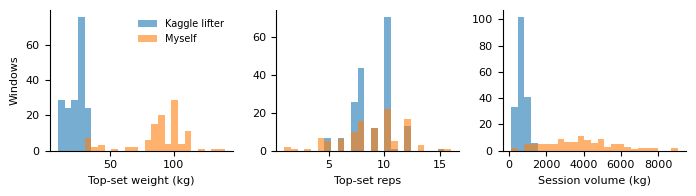

In [16]:
# %% Fig. 1 — domain shift: feature distributions of the two lifters
kaggle_df = pd.DataFrame(X_kaggle[:, -1, :], columns=feature_cols)   #last session of each window
hevy_df   = pd.DataFrame(X_hevy[:, -1, :],   columns=feature_cols)
 
fig, axes = plt.subplots(1, 3, figsize=(7, 2.0))
for ax, feat, label in zip(axes, ["weight_kg", "reps", "session_volume"],
                           ["Top-set weight (kg)", "Top-set reps", "Session volume (kg)"]):
    bins = np.histogram_bin_edges(np.concatenate([kaggle_df[feat], hevy_df[feat]]), bins=25)
    ax.hist(kaggle_df[feat], bins=bins, alpha=0.6, label="Kaggle lifter")
    ax.hist(hevy_df[feat],   bins=bins, alpha=0.6, label="Myself")
    ax.set_xlabel(label)
axes[0].set_ylabel("Windows")
axes[0].legend(fontsize=7, frameon=False)
plt.tight_layout()
plt.savefig("fig1_domain_shift.png", dpi=300)
plt.show()

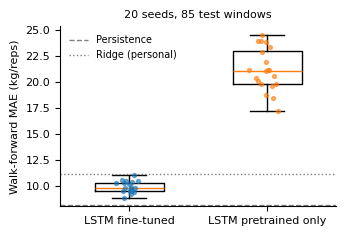

In [11]:
# %% Fig. 2 — walk-forward MAE across seeds
per_seed = wf.groupby(["model", "seed"])["mae"].mean().reset_index()
lstm_ft  = per_seed[per_seed.model == "lstm_finetuned"]["mae"]
lstm_pre = per_seed[per_seed.model == "lstm_pretrained_only"]["mae"]
 
fig, ax = plt.subplots(figsize=(3.5, 2.4))
ax.boxplot([lstm_ft, lstm_pre], widths=0.5)
ax.set_xticks([1, 2]); ax.set_xticklabels(["LSTM fine-tuned", "LSTM pretrained only"])
for i, d in enumerate([lstm_ft, lstm_pre], start=1):                  #show individual seeds
    ax.scatter(np.random.normal(i, 0.04, len(d)), d, s=8, alpha=0.6, zorder=3)
for m, ls, lab in [("persistence", "--", "Persistence"), ("ridge_personal", ":", "Ridge (personal)")]:
    ax.axhline(per_seed[per_seed.model == m]["mae"].iloc[0], ls=ls, color="grey", lw=1, label=lab)
ax.set_ylabel("Walk-forward MAE (kg/reps)")
ax.set_title(f"{per_seed.seed.nunique()} seeds, 85 test windows", fontsize=8)
ax.legend(fontsize=7, frameon=False)
plt.tight_layout()
plt.savefig("fig2_seed_mae.png", dpi=300)
plt.show()

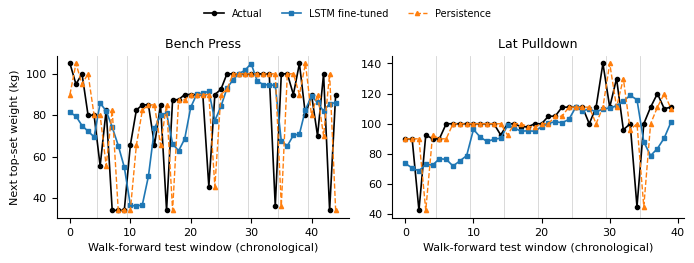

In [12]:
# %% Fig. 3 — actual vs predicted next top-set weight (walk-forward test windows)
fig, axes = plt.subplots(1, 2, figsize=(7, 2.6))
for ax, ex in zip(axes, ["Bench Press", "Lat Pulldown"]):
    d = wf[(wf.exercise == ex) & (wf.seed == SHOW_SEED)]
    lstm = d[d.model == "lstm_finetuned"].sort_values("window")
    pers = d[d.model == "persistence"].sort_values("window")
    x = np.arange(len(lstm))
    ax.plot(x, lstm.true_w.values, "o-", ms=3, lw=1.2, color="black", label="Actual")
    ax.plot(x, lstm.pred_w.values, "s-", ms=3, lw=1.2, label="LSTM fine-tuned")
    ax.plot(x, pers.pred_w.values, "^--", ms=3, lw=1.0, label="Persistence")
    for b in range(5, len(x), 5):                                     #fold boundaries
        ax.axvline(b - 0.5, color="lightgrey", lw=0.6, zorder=0)
    ax.set_title(ex, fontsize=9)
    ax.set_xlabel("Walk-forward test window (chronological)")
axes[0].set_ylabel("Next top-set weight (kg)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=7, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("fig3_wf_predictions.png", dpi=300)
plt.show()

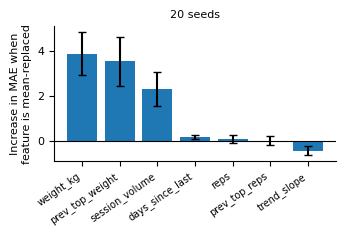

In [13]:
# %% Fig. 4 — ablation importance (held-out windows)
base = (wf[(wf.model == "lstm_finetuned") & (wf.seed.isin(abl.seed.unique()))]
        .groupby("seed")["mae"].mean())
imp = abl.groupby(["feature", "seed"])["mae"].mean().unstack("feature").sub(base, axis=0)
imp_summary = imp.agg(["mean", "std"]).T.sort_values("mean", ascending=False)
 
fig, ax = plt.subplots(figsize=(3.5, 2.4))
ax.bar(imp_summary.index, imp_summary["mean"], yerr=imp_summary["std"].fillna(0), capsize=3)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Increase in MAE when\nfeature is mean-replaced")
ax.set_title(f"{abl.seed.nunique()} seeds", fontsize=8)
plt.xticks(rotation=35, ha="right", fontsize=7)
plt.tight_layout()
plt.savefig("fig4_ablation.png", dpi=300)
plt.show()

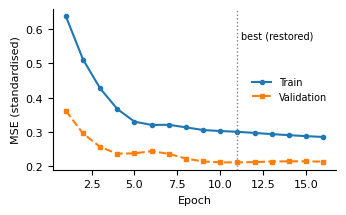

In [14]:
# %% Fig. 5 (optional) — pretraining curve for one seed
h = pre_hist[str(SHOW_SEED)]
best = int(np.argmin(h["val_loss"])) + 1
fig, ax = plt.subplots(figsize=(3.5, 2.2))
ax.plot(range(1, len(h["loss"]) + 1), h["loss"], "o-", ms=3, label="Train")
ax.plot(range(1, len(h["val_loss"]) + 1), h["val_loss"], "s--", ms=3, label="Validation")
ax.axvline(best, color="grey", ls=":", lw=1)
ax.text(best + 0.2, max(h["loss"]) * 0.9, "best (restored)", fontsize=7)
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE (standardised)")
ax.legend(fontsize=7, frameon=False)
plt.tight_layout()
plt.savefig("fig5_pretrain_curve.png", dpi=300)
plt.show()

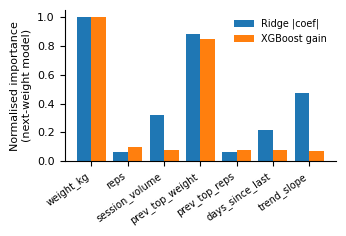

In [15]:
# %% Fig. 6 (optional) — Kaggle ridge / XGBoost importance (summed over the 5 timesteps)
nf = len(feature_cols)
ridge_imp = np.abs(baseline_result["lr_weight"].coef_).reshape(seq_len, nf).sum(axis=0)
gain = baseline_result["gb_weight"].get_booster().get_score(importance_type="gain")
xgb_imp = np.array([gain.get(f"f{j}", 0.0) for j in range(seq_len * nf)]).reshape(seq_len, nf).sum(axis=0)
norm = lambda a: a / a.max() if a.max() > 0 else a
 
x = np.arange(nf)
fig, ax = plt.subplots(figsize=(3.5, 2.4))
ax.bar(x - 0.2, norm(ridge_imp), width=0.4, label="Ridge |coef|")
ax.bar(x + 0.2, norm(xgb_imp),   width=0.4, label="XGBoost gain")
ax.set_xticks(x); ax.set_xticklabels(feature_cols, rotation=35, ha="right", fontsize=7)
ax.set_ylabel("Normalised importance\n(next-weight model)")
ax.legend(fontsize=7, frameon=False)
plt.tight_layout()
plt.savefig("fig6_kaggle_importance.png", dpi=300)
plt.show()